Ксенофонтов Константин Владимирович, студент Курса М25-555

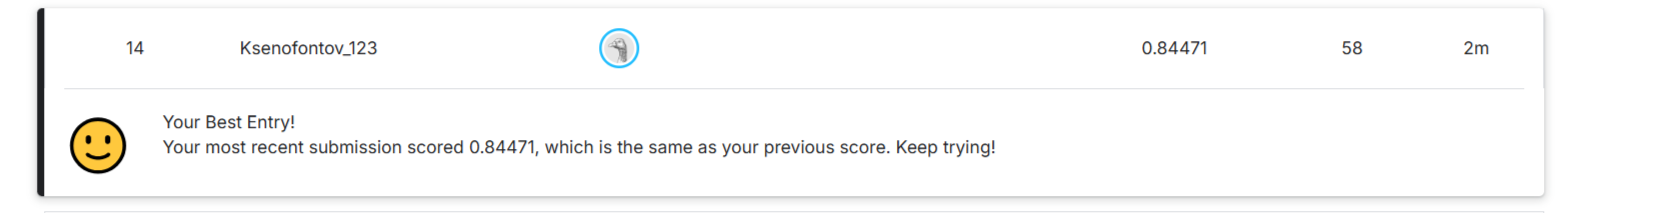

# Автоматическая кластеризация сигналов сцинтилляционного детектора

В рамках проекта нужно разработать автоматическую кластеризацию сигналов сцинтилляционного детектора. Сцинтилляционные детекторы используются для регистрации ионизирующего излучения в ядерной энергетике, радиационном контроле и физических экспериментах. 

Задача проекта состоит в том, чтобы разделить набор сигналов на три кластера: два кластера могут соответствовать разным типам частиц, например гамма-квантам и нейтронам, а третий - аномальным, шумовым или неидентифицируемым сигналам. Решение выполняется методами машинного обучения без учителя. 

Необходимо построить устойчивую модель кластеризации сигналов сцинтилляционного детектора и сформировать итоговый файл с метками кластеров для дальнейшей оценки.

In [1]:
# Импорт библиотек и настройка окружения
import os
import re
import time
import gc
import itertools
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
import missingno as msno
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans, MiniBatchKMeans, DBSCAN, Birch, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, silhouette_samples
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
import scipy.cluster.hierarchy as sch
from scipy.stats import pearsonr, norm
import opendatasets as od
from yellowbrick.cluster import silhouette_visualizer

warnings.filterwarnings("ignore")

# Воспроизводимость результатов
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True

**1. Исследование и анализ датасета (EDA)**

In [2]:
# Загрузка данных
dataset = pd.read_csv('data/Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)
print(f"Размер датасета: {dataset.shape}")
print(f"{dataset.shape[0]} сигналов, {dataset.shape[1]} признаков")
dataset = dataset.drop([0, 1, 2, 3, 504], axis=1)
dataset.columns = list(range(500))
duplicates = dataset.duplicated().sum()

print(f"Размер датасета: {dataset.shape}")
print(f"Пропущенные значения: {dataset.isnull().sum().sum()}")
print(f"Дубликатов: {duplicates}")
print('Диапазон АЦП:', dataset.values.min(), dataset.values.max())
print(f"\nСтатистика по строкам:")
print(dataset.describe().T.describe())
display(dataset.head())

Размер датасета: (23479, 505)
23479 сигналов, 505 признаков
Размер датасета: (23479, 500)
Пропущенные значения: 0
Дубликатов: 0
Диапазон АЦП: 0 14838

Статистика по строкам:
         count          mean          std           min           25%  \
count    500.0    500.000000   500.000000    500.000000    500.000000   
mean   23479.0  14796.683724    36.108334  14526.876000  14787.522000   
std        0.0    157.008997   211.887340   1613.825674    202.168917   
min    23479.0  13071.555560     2.797017      0.000000  12567.000000   
25%    23479.0  14819.218546     2.840194  14760.000000  14817.000000   
50%    23479.0  14821.632672     3.906843  14791.000000  14820.000000   
75%    23479.0  14822.942406     6.243805  14809.000000  14821.000000   
max    23479.0  14823.003961  2389.392164  14814.000000  14821.000000   

                50%           75%           max  
count    500.000000    500.000000    500.000000  
mean   14810.526000  14819.646000  14833.222000  
std       70.72984

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


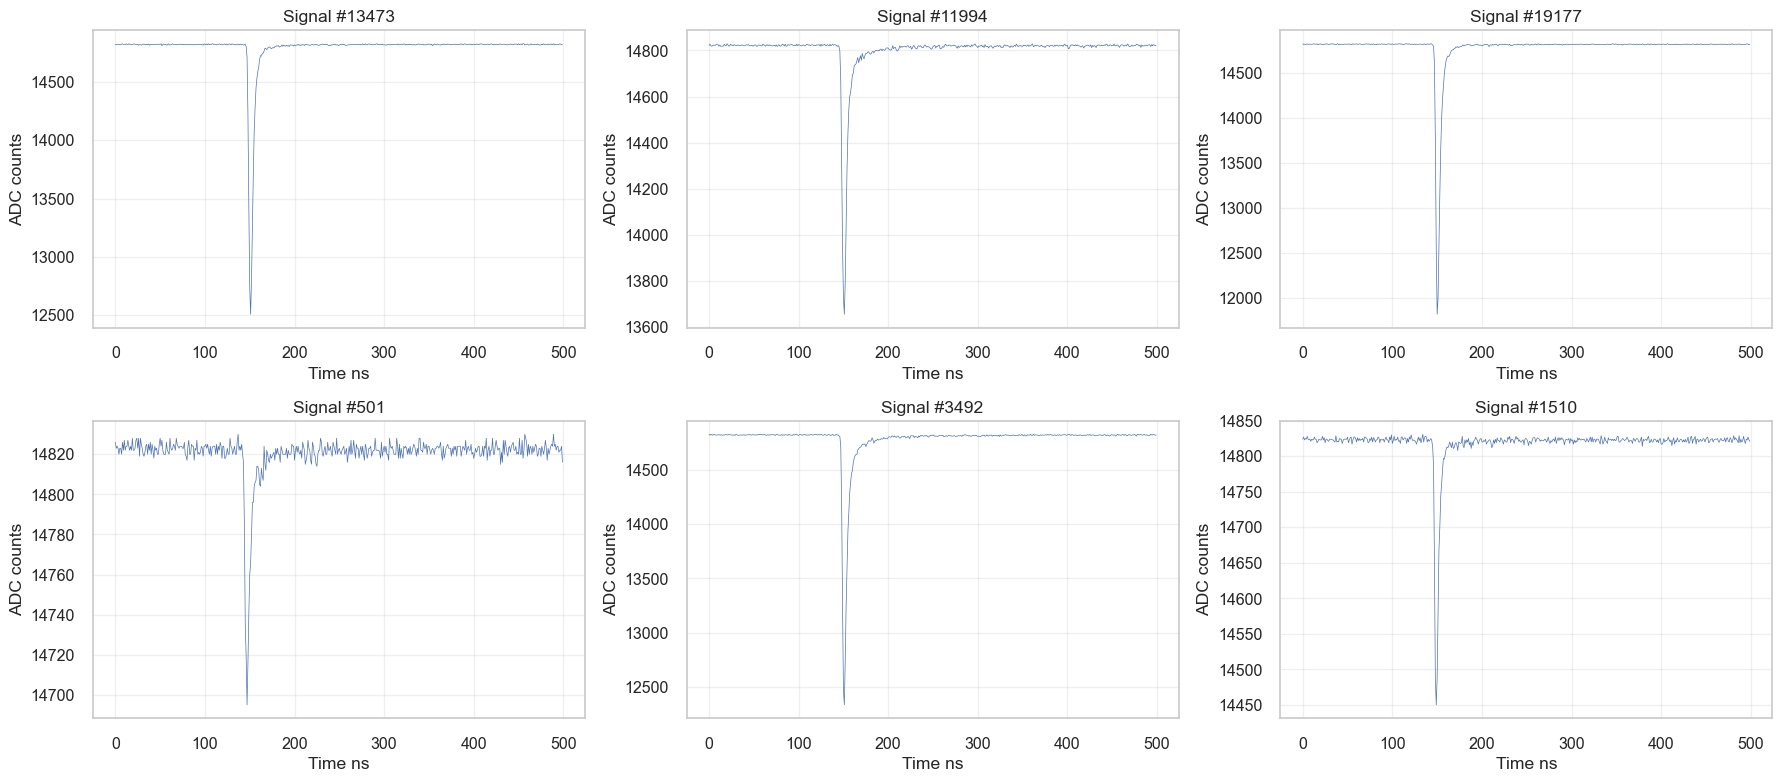


Статистика агрегированных признаков:
               mean           std           max           min          skew  \
count  23479.000000  23479.000000  23479.000000  23479.000000  23479.000000   
mean   14796.683724    161.693850  14830.711359  12987.861791     -8.447535   
std       32.209844    208.973628      1.458499   2389.308983      0.592961   
min    14596.798000     10.231617  14827.000000      0.000000    -12.116950   
25%    14788.297000     27.740063  14830.000000  12508.000000     -8.973314   
50%    14810.496000     72.155612  14831.000000  14010.000000     -8.502906   
75%    14818.034000    204.672726  14832.000000  14515.000000     -8.040935   
max    14823.788000   1484.918725  14838.000000  14719.000000     -6.125587   

           kurtosis  
count  23479.000000  
mean      77.786377  
std        9.823000  
min       41.815727  
25%       70.753813  
50%       78.379445  
75%       86.081816  
max      163.578035  


In [3]:
# Визуализация нескольких случайных сигналов
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.ravel()
sample_idx = np.random.choice(len(dataset), 6, replace=False)

for idx, ax in zip(sample_idx, axes):
    signal = dataset.iloc[idx].values
    ax.plot(signal, linewidth=0.5)
    ax.set_title(f'Signal #{idx}')
    ax.set_xlabel('Time ns')
    ax.set_ylabel('ADC counts')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Статистика сигналов
signal_stats = pd.DataFrame({
    'mean': dataset.mean(axis=1),
    'std': dataset.std(axis=1),
    'max': dataset.max(axis=1),
    'min': dataset.min(axis=1),
    'skew': dataset.skew(axis=1),
    'kurtosis': dataset.kurtosis(axis=1)
})

print("\nСтатистика агрегированных признаков:")
print(signal_stats.describe())

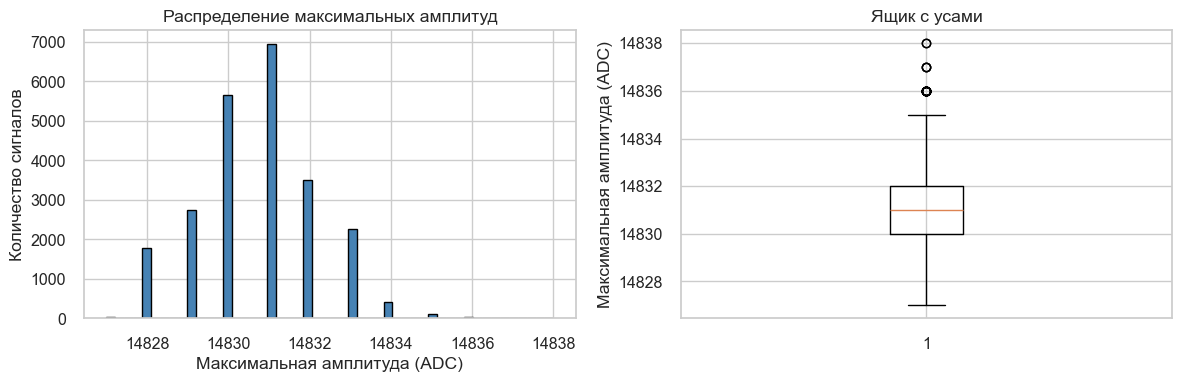

Средняя максимальная амплитуда: 14830.71
Медиана максимальной амплитуды: 14831.00
Стандартное отклонение: 1.46
Количество выбросов (амплитуда > 14835): 28
Базовая линия (первые 50 отсчётов): 14822.97 ± 0.86
Средняя корреляция между соседними отсчётами: 0.389


In [4]:
# Анализ амплитуд, базовой линии и коррееляции
max_vals = dataset.max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(max_vals, bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Максимальная амплитуда (ADC)')
axes[0].set_ylabel('Количество сигналов')
axes[0].set_title('Распределение максимальных амплитуд')

axes[1].boxplot(max_vals)
axes[1].set_ylabel('Максимальная амплитуда (ADC)')
axes[1].set_title('Ящик с усами')

plt.tight_layout()
plt.show()

print(f'Средняя максимальная амплитуда: {max_vals.mean():.2f}')
print(f'Медиана максимальной амплитуды: {max_vals.median():.2f}')
print(f'Стандартное отклонение: {max_vals.std():.2f}')
print(f'Количество выбросов (амплитуда > 14835): {np.sum(max_vals > 14835)}')

# Оценка базовой линии по первым 50 отсчётам исходного датасета
baseline_per_signal = dataset.iloc[:, :50].mean(axis=1)
baseline_mean = baseline_per_signal.mean()
baseline_std = baseline_per_signal.std()
print(f'Базовая линия (первые 50 отсчётов): {baseline_mean:.2f} ± {baseline_std:.2f}')

neighbour_corrs = [
    dataset.iloc[:, i].corr(dataset.iloc[:, i - 1])
    for i in range(1, dataset.shape[1])
]
corr_value = np.nanmean(neighbour_corrs)
print(f'Средняя корреляция между соседними отсчётами: {corr_value:.3f}')


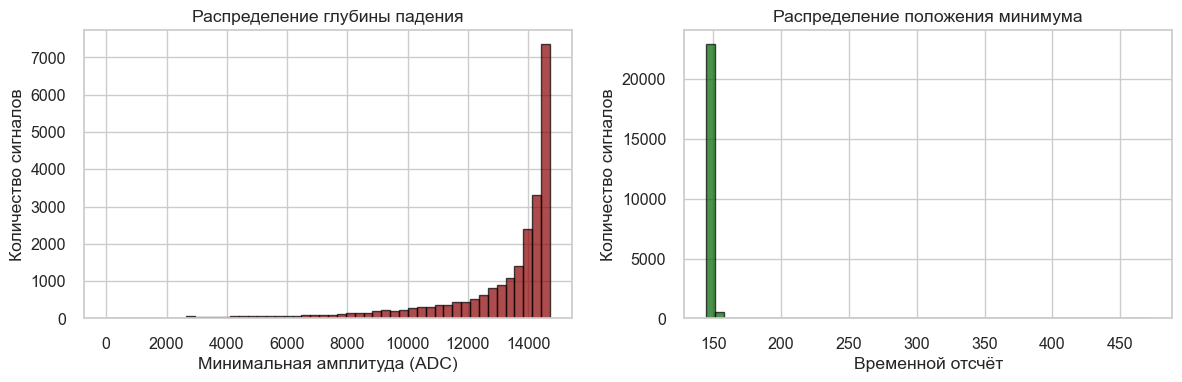

Средняя глубина падения: 12987.86
Медианная глубина: 14010.00
Среднее положение минимума: 149.6


In [5]:
# Анализ минимальных значений и положения минимума в сигналах проекта
min_vals = dataset.min(axis=1)
peak_positions_raw = dataset.idxmin(axis=1)

if peak_positions_raw.dtype == "object":
    peak_positions = (
        peak_positions_raw
        .astype(str)
        .str.replace("time_", "", regex=False)
        .astype(int)
    )
else:
    peak_positions = peak_positions_raw.astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(min_vals, bins=50, color='darkred', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Минимальная амплитуда (ADC)')
axes[0].set_ylabel('Количество сигналов')
axes[0].set_title('Распределение глубины падения')

axes[1].hist(peak_positions, bins=50, color='darkgreen', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Временной отсчёт')
axes[1].set_ylabel('Количество сигналов')
axes[1].set_title('Распределение положения минимума')

plt.tight_layout()
plt.show()

print(f'Средняя глубина падения: {min_vals.mean():.2f}')
print(f'Медианная глубина: {min_vals.median():.2f}')
print(f'Среднее положение минимума: {peak_positions.mean():.1f}')

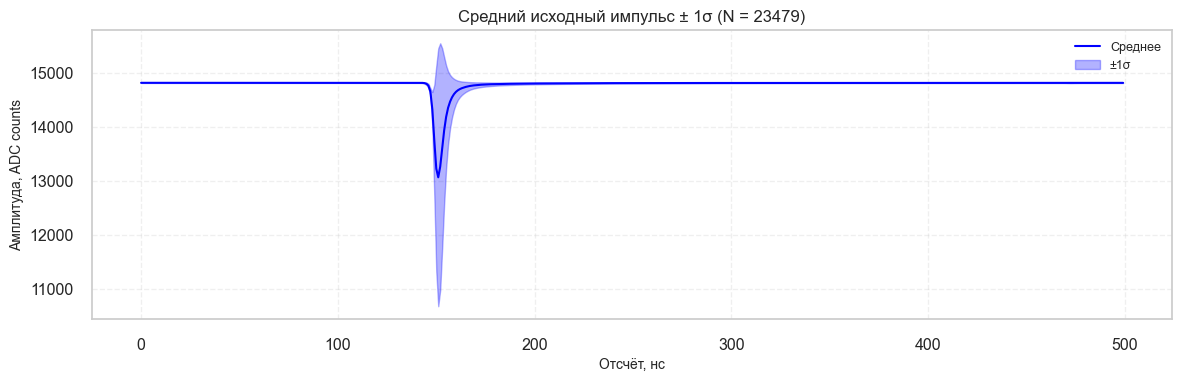

In [6]:
# Визуализация среднего импульса
if 'signal_line' in globals():
    signals_for_mean = signal_line
elif 'dataset' in globals():
    signals_for_mean = dataset.values
else:
    raise NameError("Не найдены переменные signal_line или dataset.")

# Если это DataFrame, переводим в numpy
if hasattr(signals_for_mean, "values"):
    signals_for_mean = signals_for_mean.values

mean_wave = signals_for_mean.mean(axis=0)
std_wave = signals_for_mean.std(axis=0)

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    mean_wave,
    label='Среднее',
    color='blue',
    linewidth=1.5
)

ax.fill_between(
    np.arange(signals_for_mean.shape[1]),
    mean_wave - std_wave,
    mean_wave + std_wave,
    alpha=0.3,
    label='±1σ',
    color='blue'
)

ax.set_title(
    f'Средний исходный импульс ± 1σ (N = {signals_for_mean.shape[0]})',
    fontsize=12
)
ax.set_xlabel('Отсчёт, нс', fontsize=10)
ax.set_ylabel('Амплитуда, ADC counts', fontsize=10)
ax.grid(alpha=0.3, linestyle='--')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

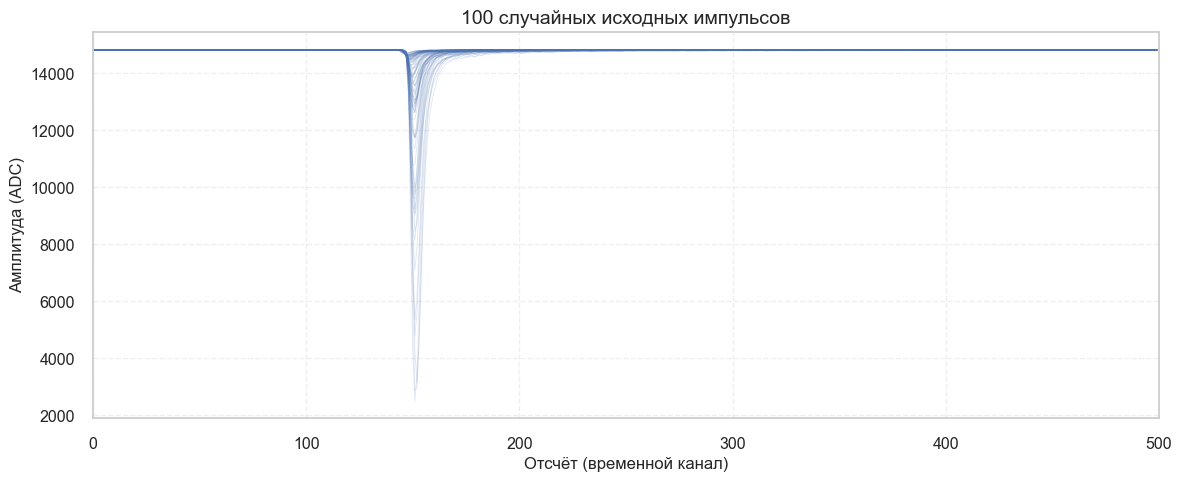

In [7]:
# Cлучайные сигналы поверх друг друга
SEED = 42
rng = np.random.default_rng(SEED)

if 'signal_line' in globals():
    signals_for_plot = signal_line
elif 'dataset' in globals():
    signals_for_plot = dataset.values
else:
    raise NameError("Не найдены переменные signal_line или dataset.")

if hasattr(signals_for_plot, "values"):
    signals_for_plot = signals_for_plot.values

n_plots = 100
n_plots = min(n_plots, signals_for_plot.shape[0])

sel = rng.choice(
    signals_for_plot.shape[0],
    size=n_plots,
    replace=False
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    signals_for_plot[sel].T,
    alpha=0.15,
    linewidth=0.7,
    color='C0'
)

ax.set_title(f'{n_plots} случайных исходных импульсов', fontsize=14)
ax.set_xlabel('Отсчёт (временной канал)', fontsize=12)
ax.set_ylabel('Амплитуда (ADC)', fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(0, signals_for_plot.shape[1])

plt.tight_layout()
plt.show()

**1. Вывод. Исследование и анализ датасета (EDA)**

1. В исходном файле содержится 23479 зарегистрированных сигналов и 505 столбцов. После предобработки осталось 23479 сигналов и 500 временных отсчётов. Пропущенные значения и дубликаты не обнаружены. 
2. Значения сигналов представлены в шкале АЦП и лежат в диапазоне от 0 до 14838. Большая часть отсчётов находится около постоянного уровня базовой линии 14823.
3. Визуализация показала, что формы импульса имеют отрицательный всплеск. 
4. Минимум сигнала расположен около отсчёта 149.6. Это означает, что положение импульса во времени достаточно стабильно. 

**2. Предобработка**

In [8]:
# предобработка сигналов
signals = dataset.copy()
baseline = dataset.iloc[:, :94].mean(axis=1).values.reshape(-1, 1)

signals_clean = baseline - dataset.values
signals_clean = np.maximum(signals_clean, 0)

signal_max = signals_clean.max(axis=1, keepdims=True)
signals_norm = signals_clean / (signal_max + 1e-8)

signal_line_corrected = signals_clean
normalized_waveforms = signals_norm

print(f'Размер после обработки: {signals_norm.shape}')
print(f'Диапазон значений: [{signals_norm.min():.2f}, {signals_norm.max():.2f}]')
print(f'Отрицательных значений после вычитания: {np.sum(signals_clean < 0)}')

Размер после обработки: (23479, 500)
Диапазон значений: [0.00, 1.00]
Отрицательных значений после вычитания: 0


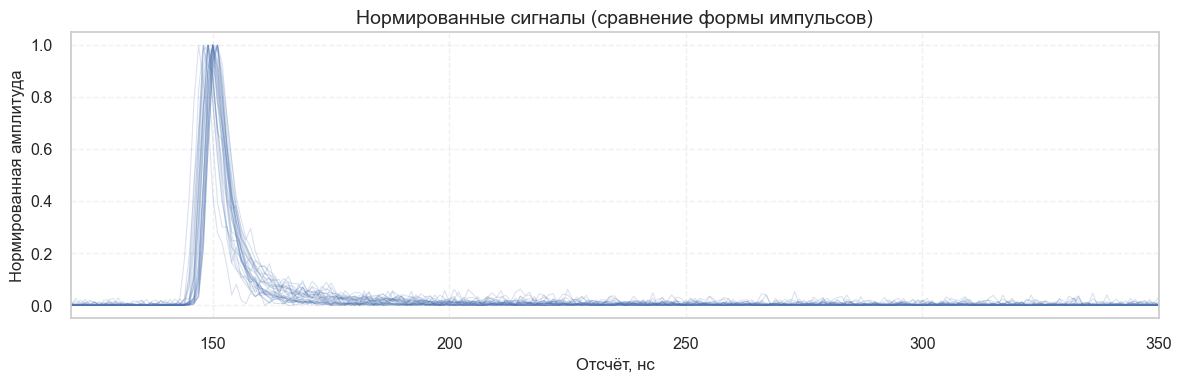

In [9]:
# Нормировка на амплитуду
peak_amps = signal_line_corrected.max(axis=1, keepdims=True)

safe_amps = np.maximum(peak_amps, 1e-9)
normalized_waveforms = signal_line_corrected / safe_amps

plt.figure(figsize=(12, 4))
plt.plot(
    normalized_waveforms[:30].T,
    alpha=0.2,
    linewidth=0.8,
    color='C0'
)

plt.title('Нормированные сигналы (сравнение формы импульсов)', fontsize=14)
plt.xlabel('Отсчёт, нс', fontsize=12)
plt.ylabel('Нормированная амплитуда', fontsize=12)
plt.xlim(120, 350)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

**2. Вывод. Предобработка**
1. Для каждого сигнала была оценена базовая линия. После этого исходный отрицательный импульс был инвертирован, бв результае чего форма сигнала стала положительной.
2. Отрицательные значения после коррекции были заменены на ноль. Далее значения кажого сигнала приведены к диапазону 0-1. Такая обработка делает сигналы сопоставимыми между собой и позволяет анализированть: соотношение быстрой и медленной компонент, положение максимума и наличие хвоста. При этом информация об абсолютной амплитуде не теряется полностью, так как далее она дополнительно используется через признак log_amp.

**3. Feature Engineering. Извлечение признаков формы импульса**

Если использовать все 500 временных отсчётов напрямую для кластеризации, то результаты получаются неудовлетворительными: такие данные имеют высокую размерность, имеют шум и приводят к нестабильной работе моделей без учителя. Поэтому нужно сделать преобразования в компактный набор физически интерпретируемых признаков.

Примменим ожидаемое положения пика **peak_position = 150**. Основные признаки отражают соотношение быстрой и медленной компонент сигнала: 
- **r_long** описывает долю хвостовой части импульса,
- **r_short** - долю быстрой компоненты,
- **ratio** показывает их относительное соотношение. 
- Дополнительно рассчитываются признаки **asymmetry** и **log_amp**.

Признак **asymmetry** показывает смещение реального максимума относительно ожидаемой позиции пика, а **log_amp** сохраняет информацию об абсолютной амплитуде сигнала после коррекции базовой линии. Таким образом, итоговое признаковое пространство включает как характеристики формы импульса, так и информацию о его амплитуде.


In [10]:
# Извлечение признаков
peak_position = 150
eps = 1e-8

signals_norm_final = signals_norm
signals_clean_final = signals_clean

# Интегральные признаки
total_integral = signals_norm_final[:, peak_position-5:peak_position+99].sum(axis=1)
tail_integral  = signals_norm_final[:, peak_position+15:peak_position+99].sum(axis=1)
fast_integral  = signals_norm_final[:, peak_position+5:peak_position+25].sum(axis=1)

qt_safe = np.maximum(np.abs(total_integral), eps)
r_long  = tail_integral / qt_safe
r_short = fast_integral / qt_safe
ratio   = r_long / (r_short + eps)

asymmetry = (peak_position - np.argmax(signals_norm_final, axis=1)) / 50

amplitude = signals_clean_final.max(axis=1)
log_amp = np.log10(amplitude + 1)

X_features = np.column_stack([
    r_long,
    r_short,
    ratio,
    asymmetry,
    log_amp
])

feat = pd.DataFrame(
    X_features,
    columns=[
        'r_long',
        'r_short',
        'ratio',
        'asymmetry',
        'log_amp'
    ]
)

feat = feat.replace([np.inf, -np.inf], np.nan)
feat = feat.fillna(feat.median())

feat_final = feat.copy()
X_features_final = X_features.copy()

print(f'Признаков: {X_features.shape[1]}')
print(f'Диапазон r_long: [{feat["r_long"].min():.4f}, {feat["r_long"].max():.4f}]')
print(f'Среднее r_long: {feat["r_long"].mean():.4f}')

display(feat.describe().round(4))

Признаков: 5
Диапазон r_long: [0.0370, 0.3195]
Среднее r_long: 0.1312


,r_long,r_short,ratio,asymmetry,log_amp
count,23479.0000,23479.0000,23479.0000,23479.0000,23479.0000
mean,0.1312,0.2060,0.6694,0.0074,2.9455
std,0.0575,0.0548,0.3407,0.0498,0.5353
min,0.0370,0.0321,0.1961,-6.4400,2.0223
25%,0.0687,0.1665,0.4018,-0.0200,2.4902
50%,0.1428,0.2135,0.6369,0.0000,2.9105
75%,0.1800,0.2508,0.8213,0.0200,3.3648
max,0.3195,0.3542,3.8669,0.1000,4.1710


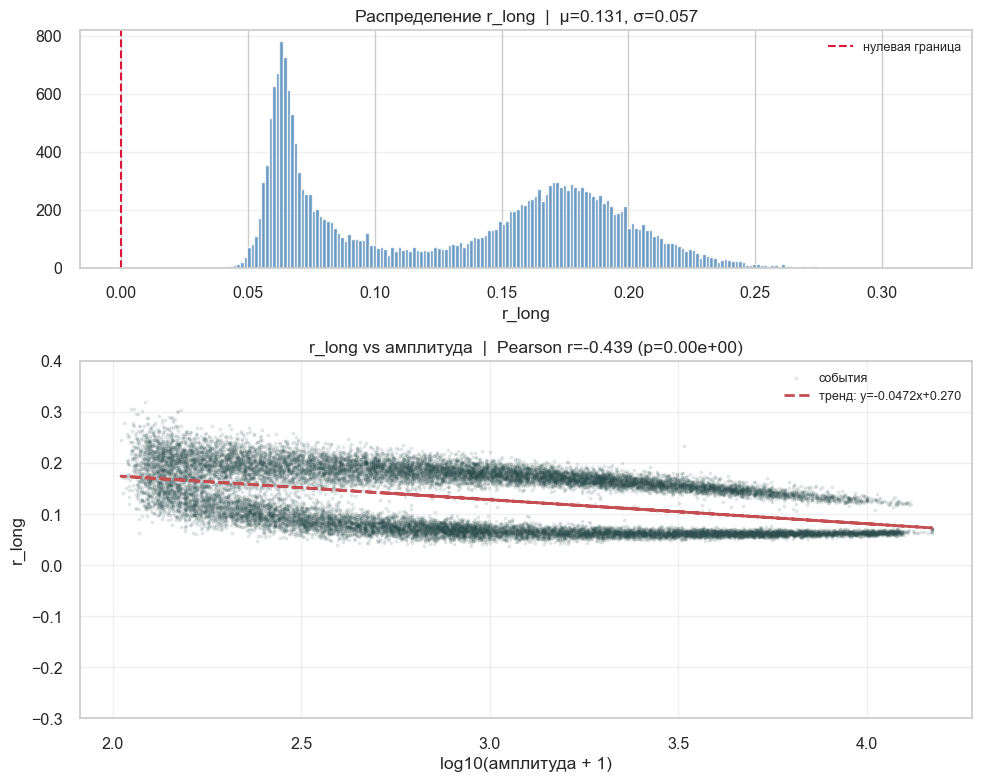

In [11]:
peak_amp = signal_line_corrected.max(axis=1)
log_amp = np.log10(peak_amp + 1)
corr, pval = pearsonr(log_amp, feat['r_long'])

fig, axes = plt.subplots(2, 1, figsize=(10, 8), height_ratios=[1, 1.5])

# Гистограмма с аннотацией
axes[0].hist(feat['r_long'], bins=200, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='crimson', lw=1.5, ls='--', label='нулевая граница')
axes[0].set_title(f'Распределение r_long  |  μ={feat["r_long"].mean():.3f}, σ={feat["r_long"].std():.3f}')
axes[0].set_xlabel('r_long')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Scatter + линия тренда + корреляция
axes[1].scatter(log_amp, feat['r_long'], s=3, alpha=0.1, color='darkslategray', label='события')
z = np.polyfit(log_amp, feat['r_long'], 1)
p = np.poly1d(z)
axes[1].plot(log_amp, p(log_amp), 'r--', lw=2, label=f'тренд: y={z[0]:.4f}x+{z[1]:.3f}')
axes[1].set_title(f'r_long vs амплитуда  |  Pearson r={corr:.3f} (p={pval:.2e})')
axes[1].set_xlabel('log10(амплитуда + 1)')
axes[1].set_ylabel('r_long')
axes[1].set_ylim(-0.3, 0.4)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

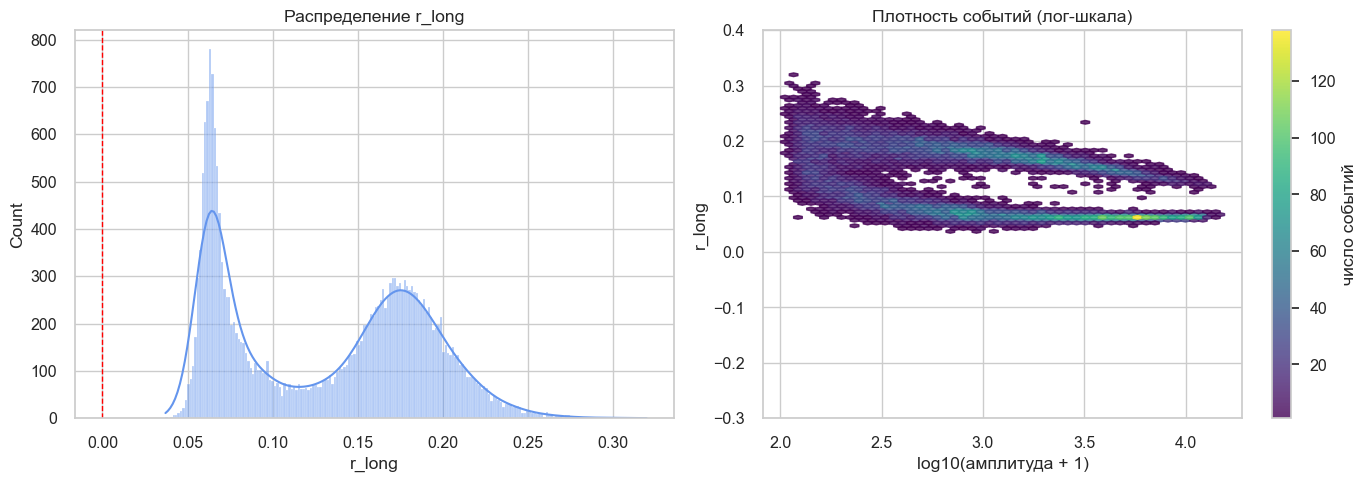

In [12]:
log_amp = np.log10(peak_amp + 1)
df_plot = pd.DataFrame({'log_amp': log_amp, 'r_long': feat['r_long']})

fig = plt.figure(figsize=(14, 5))

# Гистограмма + KDE
ax1 = plt.subplot(1, 2, 1)
sns.histplot(data=df_plot, x='r_long', bins=200, kde=True, color='cornflowerblue', ax=ax1)
ax1.axvline(0, color='red', ls='--', lw=1)
ax1.set_title('Распределение r_long')

# Hexbin вместо scatter (лучше для >10⁴ точек)
ax2 = plt.subplot(1, 2, 2)
hb = ax2.hexbin(df_plot['log_amp'], df_plot['r_long'], 
                gridsize=50, cmap='viridis', mincnt=1, alpha=0.8)
ax2.set_xlabel('log10(амплитуда + 1)')
ax2.set_ylabel('r_long')
ax2.set_title('Плотность событий (лог-шкала)')
ax2.set_ylim(-0.3, 0.4)
plt.colorbar(hb, ax=ax2, label='число событий')

plt.tight_layout()
plt.show()

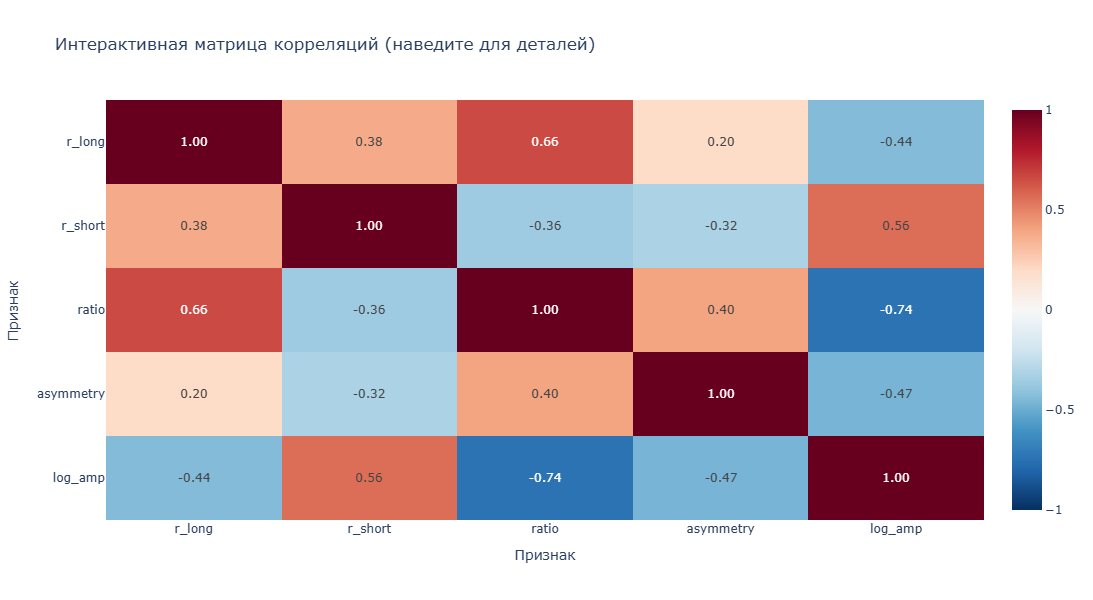

In [13]:
import plotly.express as px

corr = feat.corr().round(3)
fig = px.imshow(
    corr,
    text_auto='.2f',
    aspect='auto',
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    title='Интерактивная матрица корреляций (наведите для деталей)'
)
fig.update_layout(
    xaxis_title='Признак',
    yaxis_title='Признак',
    height=600,
    width=700
)
fig.show()
# Для сохранения: fig.write_html('correlation_map.html')

In [14]:
# Автоматически выбираем только числовые колонки
numeric_cols = feat.select_dtypes(include='number').columns.tolist()
print(f"Найдено числовых признаков: {len(numeric_cols)}")

# Функция расчёта корреляции с p-value
def corr_with_pvalue(df, col1, col2):
    mask = df[[col1, col2]].notna().all(axis=1)
    if mask.sum() < 3:  # Защита от ошибок при малом кол-ве точек
        return np.nan, np.nan
    
    res = pearsonr(df.loc[mask, col1], df.loc[mask, col2])
    # Совместимо со всеми версиями scipy (старые возвращают кортеж, новые - объект)
    corr = res.statistic if hasattr(res, 'statistic') else res[0]
    pval = res.pvalue if hasattr(res, 'pvalue') else res[1]
    return corr, pval

# Вычисляем попарные корреляции
significant_corrs = []
total_pairs = len(numeric_cols) * (len(numeric_cols) - 1) // 2
print(f" Вычисляю {total_pairs} парных корреляций...")

for i, col1 in enumerate(numeric_cols):
    for col2 in numeric_cols[i+1:]:
        corr, pval = corr_with_pvalue(feat, col1, col2)
        if pd.notna(pval) and pval < 0.05:
            significant_corrs.append({
                'feature_1': col1,
                'feature_2': col2,
                'pearson_r': corr,
                'p_value': pval,
                'abs_r': abs(corr)
            })

# Формируем итоговую таблицу
corr_df = pd.DataFrame(significant_corrs).sort_values('abs_r', ascending=False)
print("\nТоп-15 значимых корреляций (p < 0.05):")
print(corr_df[['feature_1', 'feature_2', 'pearson_r', 'p_value']].head(15).to_string(index=False))

Найдено числовых признаков: 5
 Вычисляю 10 парных корреляций...

Топ-15 значимых корреляций (p < 0.05):
feature_1 feature_2  pearson_r       p_value
    ratio   log_amp  -0.742971  0.000000e+00
   r_long     ratio   0.659908  0.000000e+00
  r_short   log_amp   0.559649  0.000000e+00
asymmetry   log_amp  -0.468758  0.000000e+00
   r_long   log_amp  -0.439242  0.000000e+00
    ratio asymmetry   0.403627  0.000000e+00
   r_long   r_short   0.378010  0.000000e+00
  r_short     ratio  -0.359792  0.000000e+00
  r_short asymmetry  -0.320685  0.000000e+00
   r_long asymmetry   0.194908 9.638352e-200


**3. Вывод Feature Engineering. Подбор признаков, их анализ и оценка важности**

Сигналы (500 шт.) были преобразованы в компактный набор из 5 признаков: **r_long**, **r_short**, **ratio**, **asymmetry** и **log_amp**.

Признаки **r_long** и **r_short** описывают вклад медленной и быстрой компонент импульса, а **ratio** отражает их соотношение. Эти характеристики важны для задачи разделения сигналов, так как разные типы частиц могут формировать импульсы с различной формой затухания. Признак **asymmetry** показывает смещение реального максимума сигнала относительно ожидаемой позиции пика, что позволяет учитывать возможные различия во временной форме импульса. Признак **log_amp** сохраняет информацию об амплитуде сигнала после коррекции базовой линии, но в сглаженном логарифмическом масштабе.

**4. Кластеризация, обучение и выбор лучшей модели**

В дальнейшем выбрано **k=3**, так как это исходит из постановки задачи. Сигналы должны быть разделены на три класса - два типа частиц и третий кластер аномальных сигналов.

In [15]:
SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", font_scale=1.05)

def remap_labels_by_size(labels):
    """
    Перенумеровывает кластеры так же, как в разделе 5:
    самый большой кластер -> 0, следующий -> 1, самый маленький -> 2.
    """
    unique, counts = np.unique(labels, return_counts=True)
    order = unique[np.argsort(counts)[::-1]]
    mapping = {old: new for new, old in enumerate(order)}
    return np.array([mapping[label] for label in labels])


def evaluate_and_log(X_metric, lbl, name, log_dict, metrics_list):
    """
    Оценивает модели теми же метриками, что и раздел 5:
    Silhouette и Davies-Bouldin в том пространстве, где обучалась модель.
    Для финального пайплайна это StandardScaler + PCA(3).
    """
    lbl = remap_labels_by_size(lbl)

    sil = silhouette_score(X_metric, lbl)
    db = davies_bouldin_score(X_metric, lbl)
    sizes = dict(zip(*np.unique(lbl, return_counts=True)))

    print(f' {name}:')
    print(f'   ├─ Silhouette: {sil:.4f}  |  Davies-Bouldin: {db:.4f}')
    print(f'   └─ Cluster sizes: {sizes}\n')

    log_dict[name] = {
        'labels': lbl,
        'silhouette': sil,
        'davies_bouldin': db,
        'sizes': sizes
    }

    metrics_list.append({
        'Model': name,
        'Sil': sil,
        'DB': db
    })

    return sil

def make_scaled_pca_features(data, n_components=3):
    """
    Масштабирование и PCA в логике раздела 5.
    Если признаков меньше 3, PCA берёт максимально возможное число компонент.
    Для одного признака PCA не применяется, остаётся StandardScaler.
    """
    X_scaled = StandardScaler().fit_transform(data)

    n_features = X_scaled.shape[1]
    n_comp = min(n_components, n_features)

    if n_comp >= 2:
        pca_local = PCA(n_components=n_comp, random_state=SEED)
        X_metric = pca_local.fit_transform(X_scaled)
        explained = pca_local.explained_variance_ratio_.sum()
    else:
        X_metric = X_scaled
        explained = 1.0

    return X_metric, explained


log_results = {}
metrics_log = []

print(" ЕДИНОЕ ПРОСТРАНСТВО ОЦЕНКИ КАК В РАЗДЕЛЕ 5")
X_section5, pca_explained = make_scaled_pca_features(feat.values, n_components=3)
print(f'PCA(3) explained variance на всех признаках: {pca_explained:.4f}')

print("\n ЭКСПЕРИМЕНТ 1: Базовые модели в пространстве StandardScaler + PCA(3)")
km = KMeans(
    n_clusters=3,
    n_init=20,
    random_state=SEED
).fit(X_section5)

evaluate_and_log(
    X_section5,
    km.labels_,
    'KMeans (StandardScaler + PCA3)',
    log_results,
    metrics_log
)

gmm_full = GaussianMixture(
    n_components=3,
    covariance_type='full',
    reg_covar=1e-4,
    n_init=20,
    max_iter=500,
    random_state=SEED
)

labels_gmm_full = gmm_full.fit_predict(X_section5)

evaluate_and_log(
    X_section5,
    labels_gmm_full,
    'GMM full (StandardScaler + PCA3)',
    log_results,
    metrics_log
)

print("\n ЭКСПЕРИМЕНТ 2: Варианты covariance_type для GMM в PCA(3)")
for cov in ['full', 'tied', 'diag']:
    g = GaussianMixture(
        n_components=3,
        covariance_type=cov,
        reg_covar=1e-4,
        n_init=20,
        max_iter=500,
        random_state=SEED
    )

    labels = g.fit_predict(X_section5)

    evaluate_and_log(
        X_section5,
        labels,
        f'GMM {cov} (StandardScaler + PCA3)',
        log_results,
        metrics_log
    )


print("\n ЭКСПЕРИМЕНТ 3: Agglomerative в пространстве StandardScaler + PCA(3)")
for link in ['ward', 'complete', 'average']:
    h = AgglomerativeClustering(
        n_clusters=3,
        linkage=link
    ).fit(X_section5)

    evaluate_and_log(
        X_section5,
        h.labels_,
        f'Agglomerative {link} (StandardScaler + PCA3)',
        log_results,
        metrics_log
    )



print("\n ЭКСПЕРИМЕНТ 4: Ablation study через StandardScaler + PCA до 3 компонент")
feature_sets = {
    "GMM 1D (r_long)": ['r_long'],
    "GMM (PSD-признаки)": ['r_long', 'r_short', 'ratio'],
    "GMM (амплитуда+пик)": ['asymmetry', 'log_amp'],
    "GMM (все признаки Final_ML)": ['r_long', 'r_short', 'ratio', 'asymmetry', 'log_amp']
}

for name, cols in feature_sets.items():
    X_tmp, explained = make_scaled_pca_features(feat[cols].values, n_components=3)

    print(f'   {name}: признаки={cols}, explained={explained:.4f}')

    g = GaussianMixture(
        n_components=3,
        covariance_type='full',
        reg_covar=1e-4,
        n_init=20,
        max_iter=500,
        random_state=SEED
    )

    labels = g.fit_predict(X_tmp)

    evaluate_and_log(
        X_tmp,
        labels,
        name,
        log_results,
        metrics_log
    )


df_metrics = (
    pd.DataFrame(metrics_log)
    .sort_values('Sil', ascending=False)
    .reset_index(drop=True)
)

print("\n СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ:")

display(
    df_metrics.style
    .highlight_max(subset=['Sil'], color='#d4edda')
    .highlight_min(subset=['DB'], color='#f8d7da')
)


best_model_key = 'GMM (все признаки Final_ML)'
best_labels = log_results[best_model_key]['labels']
final_labels = best_labels

print(f"\nФинально зафиксирована модель: {best_model_key}")
print("Используется результат: StandardScaler + PCA(3) + GMM")

print(f"Silhouette: {log_results[best_model_key]['silhouette']:.4f}")
print(f"Davies-Bouldin: {log_results[best_model_key]['davies_bouldin']:.4f}")

print("\nРаспределение кластеров:")
print(dict(zip(*np.unique(final_labels, return_counts=True))))

 ЕДИНОЕ ПРОСТРАНСТВО ОЦЕНКИ КАК В РАЗДЕЛЕ 5
PCA(3) explained variance на всех признаках: 0.9512

 ЭКСПЕРИМЕНТ 1: Базовые модели в пространстве StandardScaler + PCA(3)
 KMeans (StandardScaler + PCA3):
   ├─ Silhouette: 0.4639  |  Davies-Bouldin: 0.7815
   └─ Cluster sizes: {np.int64(0): np.int64(8884), np.int64(1): np.int64(8564), np.int64(2): np.int64(6031)}

 GMM full (StandardScaler + PCA3):
   ├─ Silhouette: 0.4025  |  Davies-Bouldin: 0.7964
   └─ Cluster sizes: {np.int64(0): np.int64(11983), np.int64(1): np.int64(11495), np.int64(2): np.int64(1)}


 ЭКСПЕРИМЕНТ 2: Варианты covariance_type для GMM в PCA(3)
 GMM full (StandardScaler + PCA3):
   ├─ Silhouette: 0.4025  |  Davies-Bouldin: 0.7964
   └─ Cluster sizes: {np.int64(0): np.int64(11983), np.int64(1): np.int64(11495), np.int64(2): np.int64(1)}

 GMM tied (StandardScaler + PCA3):
   ├─ Silhouette: 0.3551  |  Davies-Bouldin: 0.7102
   └─ Cluster sizes: {np.int64(0): np.int64(18707), np.int64(1): np.int64(4771), np.int64(2): np.int

,Model,Sil,DB
0,Agglomerative average (StandardScaler + PCA3),0.667309,0.200482
1,GMM 1D (r_long),0.546246,0.882528
2,GMM (PSD-признаки),0.507530,0.861114
3,GMM (амплитуда+пик),0.478479,0.410092
4,KMeans (StandardScaler + PCA3),0.463945,0.781516
5,GMM (все признаки Final_ML),0.402529,0.796374
6,GMM full (StandardScaler + PCA3),0.402529,0.796374
7,GMM full (StandardScaler + PCA3),0.402529,0.796374
8,Agglomerative ward (StandardScaler + PCA3),0.394542,0.817779
9,GMM diag (StandardScaler + PCA3),0.384681,1.071384



Финально зафиксирована модель: GMM (все признаки Final_ML)
Используется результат: StandardScaler + PCA(3) + GMM
Silhouette: 0.4025
Davies-Bouldin: 0.7964

Распределение кластеров:
{np.int64(0): np.int64(11983), np.int64(1): np.int64(11495), np.int64(2): np.int64(1)}


,Model,Silhouette,Davies-Bouldin,Imbalance,Cluster_sizes
0,Agglomerative average (StandardScaler + PCA3),0.6673,0.2005,23474.00,"{np.int64(0): np.int64(23474), np.int64(1): np.int64(4), np.int64(2): np.int64(1)}"
1,GMM 1D (r_long),0.5462,0.8825,1.47,"{np.int64(0): np.int64(9038), np.int64(1): np.int64(8285), np.int64(2): np.int64(6156)}"
2,GMM (PSD-признаки),0.5075,0.8611,1.66,"{np.int64(0): np.int64(9849), np.int64(1): np.int64(7706), np.int64(2): np.int64(5924)}"
3,GMM (амплитуда+пик),0.4785,0.4101,16668.00,"{np.int64(0): np.int64(16668), np.int64(1): np.int64(6810), np.int64(2): np.int64(1)}"
4,KMeans (StandardScaler + PCA3),0.4639,0.7815,1.47,"{np.int64(0): np.int64(8884), np.int64(1): np.int64(8564), np.int64(2): np.int64(6031)}"
5,GMM (все признаки Final_ML),0.4025,0.7964,11983.00,"{np.int64(0): np.int64(11983), np.int64(1): np.int64(11495), np.int64(2): np.int64(1)}"
6,GMM full (StandardScaler + PCA3),0.4025,0.7964,11983.00,"{np.int64(0): np.int64(11983), np.int64(1): np.int64(11495), np.int64(2): np.int64(1)}"
7,Agglomerative ward (StandardScaler + PCA3),0.3945,0.8178,1.61,"{np.int64(0): np.int64(9319), np.int64(1): np.int64(8360), np.int64(2): np.int64(5800)}"
8,GMM diag (StandardScaler + PCA3),0.3847,1.0714,79.05,"{np.int64(0): np.int64(11937), np.int64(1): np.int64(11391), np.int64(2): np.int64(151)}"
9,GMM tied (StandardScaler + PCA3),0.3551,0.7102,18707.00,"{np.int64(0): np.int64(18707), np.int64(1): np.int64(4771), np.int64(2): np.int64(1)}"


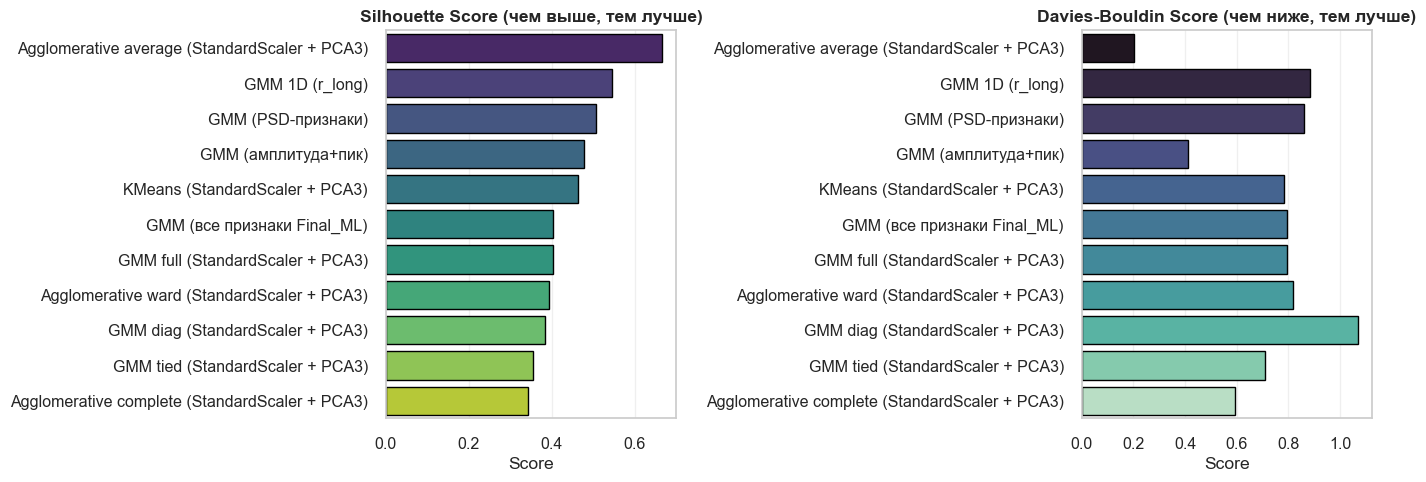

In [16]:
# Визуализация кластеризации
summary_data = []

for name, data in log_results.items():
    labels = data['labels']
    sil = data['silhouette']
    db = data['davies_bouldin']
    sizes = data['sizes']

    counts = list(sizes.values())
    imbalance = max(counts) / min(counts) if min(counts) > 0 else np.inf

    summary_data.append({
        'Model': name,
        'Silhouette': sil,
        'Davies-Bouldin': db,
        'Imbalance': imbalance,
        'Cluster_sizes': str(sizes)
    })

df_summary = (
    pd.DataFrame(summary_data)
    .sort_values('Silhouette', ascending=False)
    .reset_index(drop=True)
)

display(
    df_summary.style.format({
        'Silhouette': '{:.4f}',
        'Davies-Bouldin': '{:.4f}',
        'Imbalance': '{:.2f}'
    })
)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    x='Silhouette',
    y='Model',
    data=df_summary,
    ax=axes[0],
    palette='viridis',
    edgecolor='black'
)

axes[0].set_title('Silhouette Score (чем выше, тем лучше)', fontweight='bold')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('')
axes[0].grid(axis='x', alpha=0.3)


sns.barplot(
    x='Davies-Bouldin',
    y='Model',
    data=df_summary,
    ax=axes[1],
    palette='mako',
    edgecolor='black'
)

axes[1].set_title('Davies-Bouldin Score (чем ниже, тем лучше)', fontweight='bold')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

Модели для визуального сравнения:
- KMeans (StandardScaler + PCA3)
- GMM full (StandardScaler + PCA3)
- GMM tied (StandardScaler + PCA3)
- GMM diag (StandardScaler + PCA3)
- Agglomerative ward (StandardScaler + PCA3)
- Agglomerative complete (StandardScaler + PCA3)
- Agglomerative average (StandardScaler + PCA3)
- GMM 1D (r_long)
- GMM (PSD-признаки)
- GMM (амплитуда+пик)
- GMM (все признаки Final_ML)


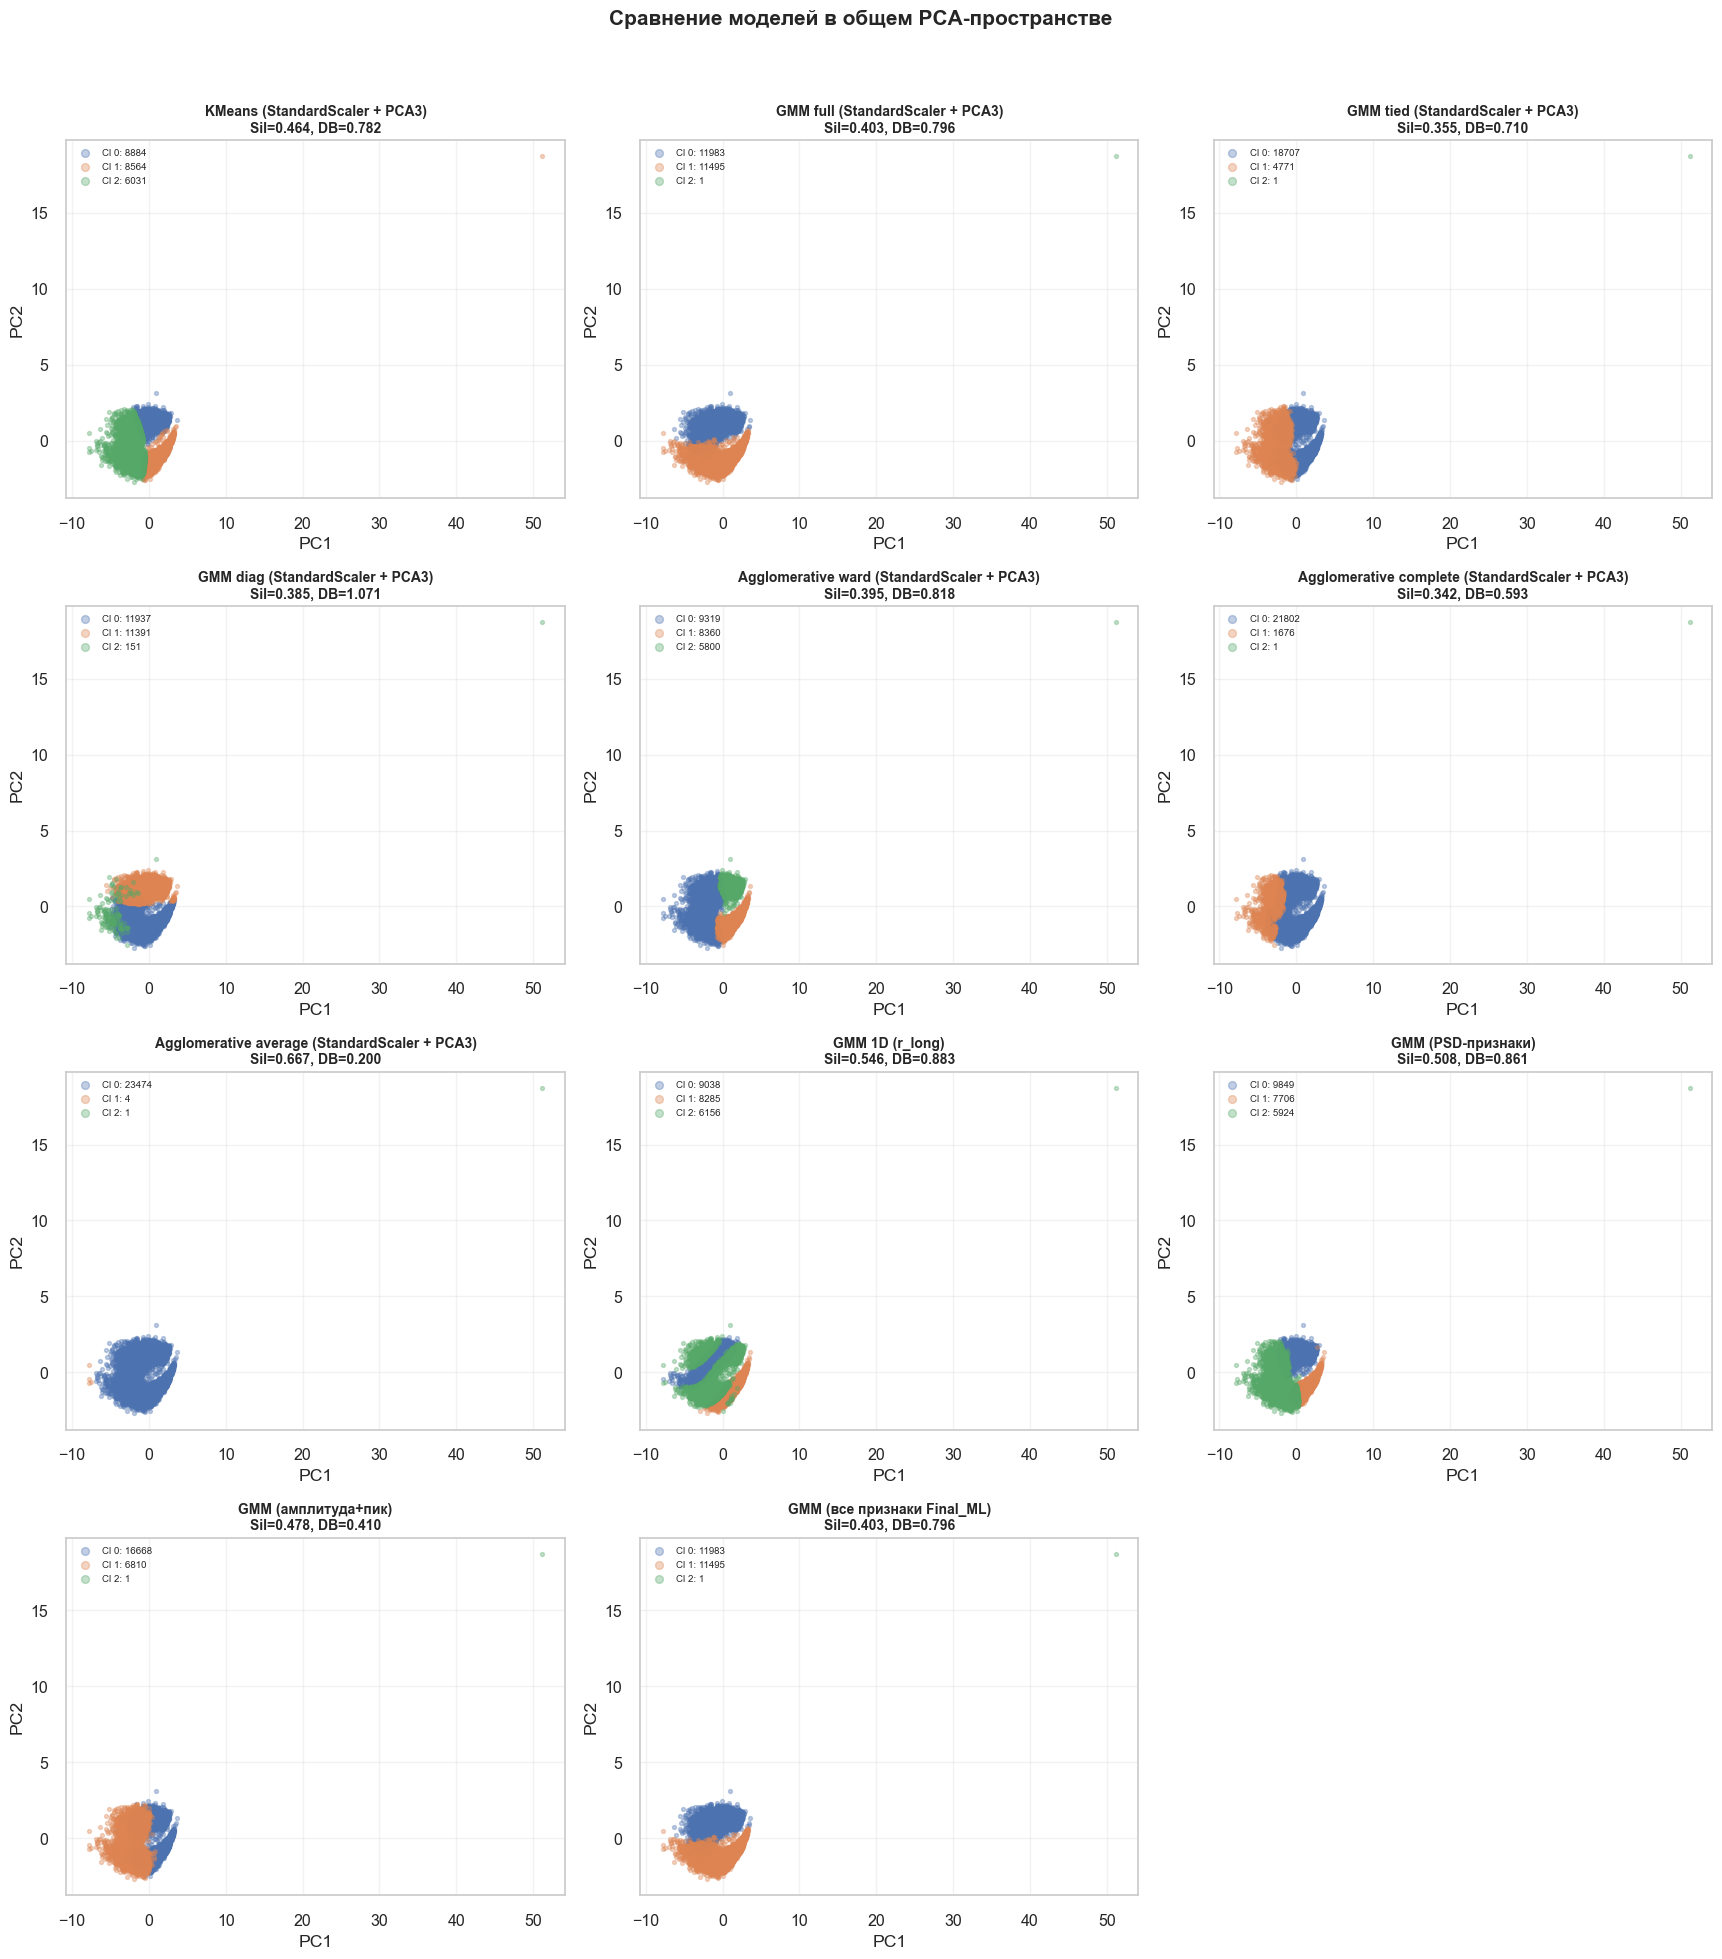

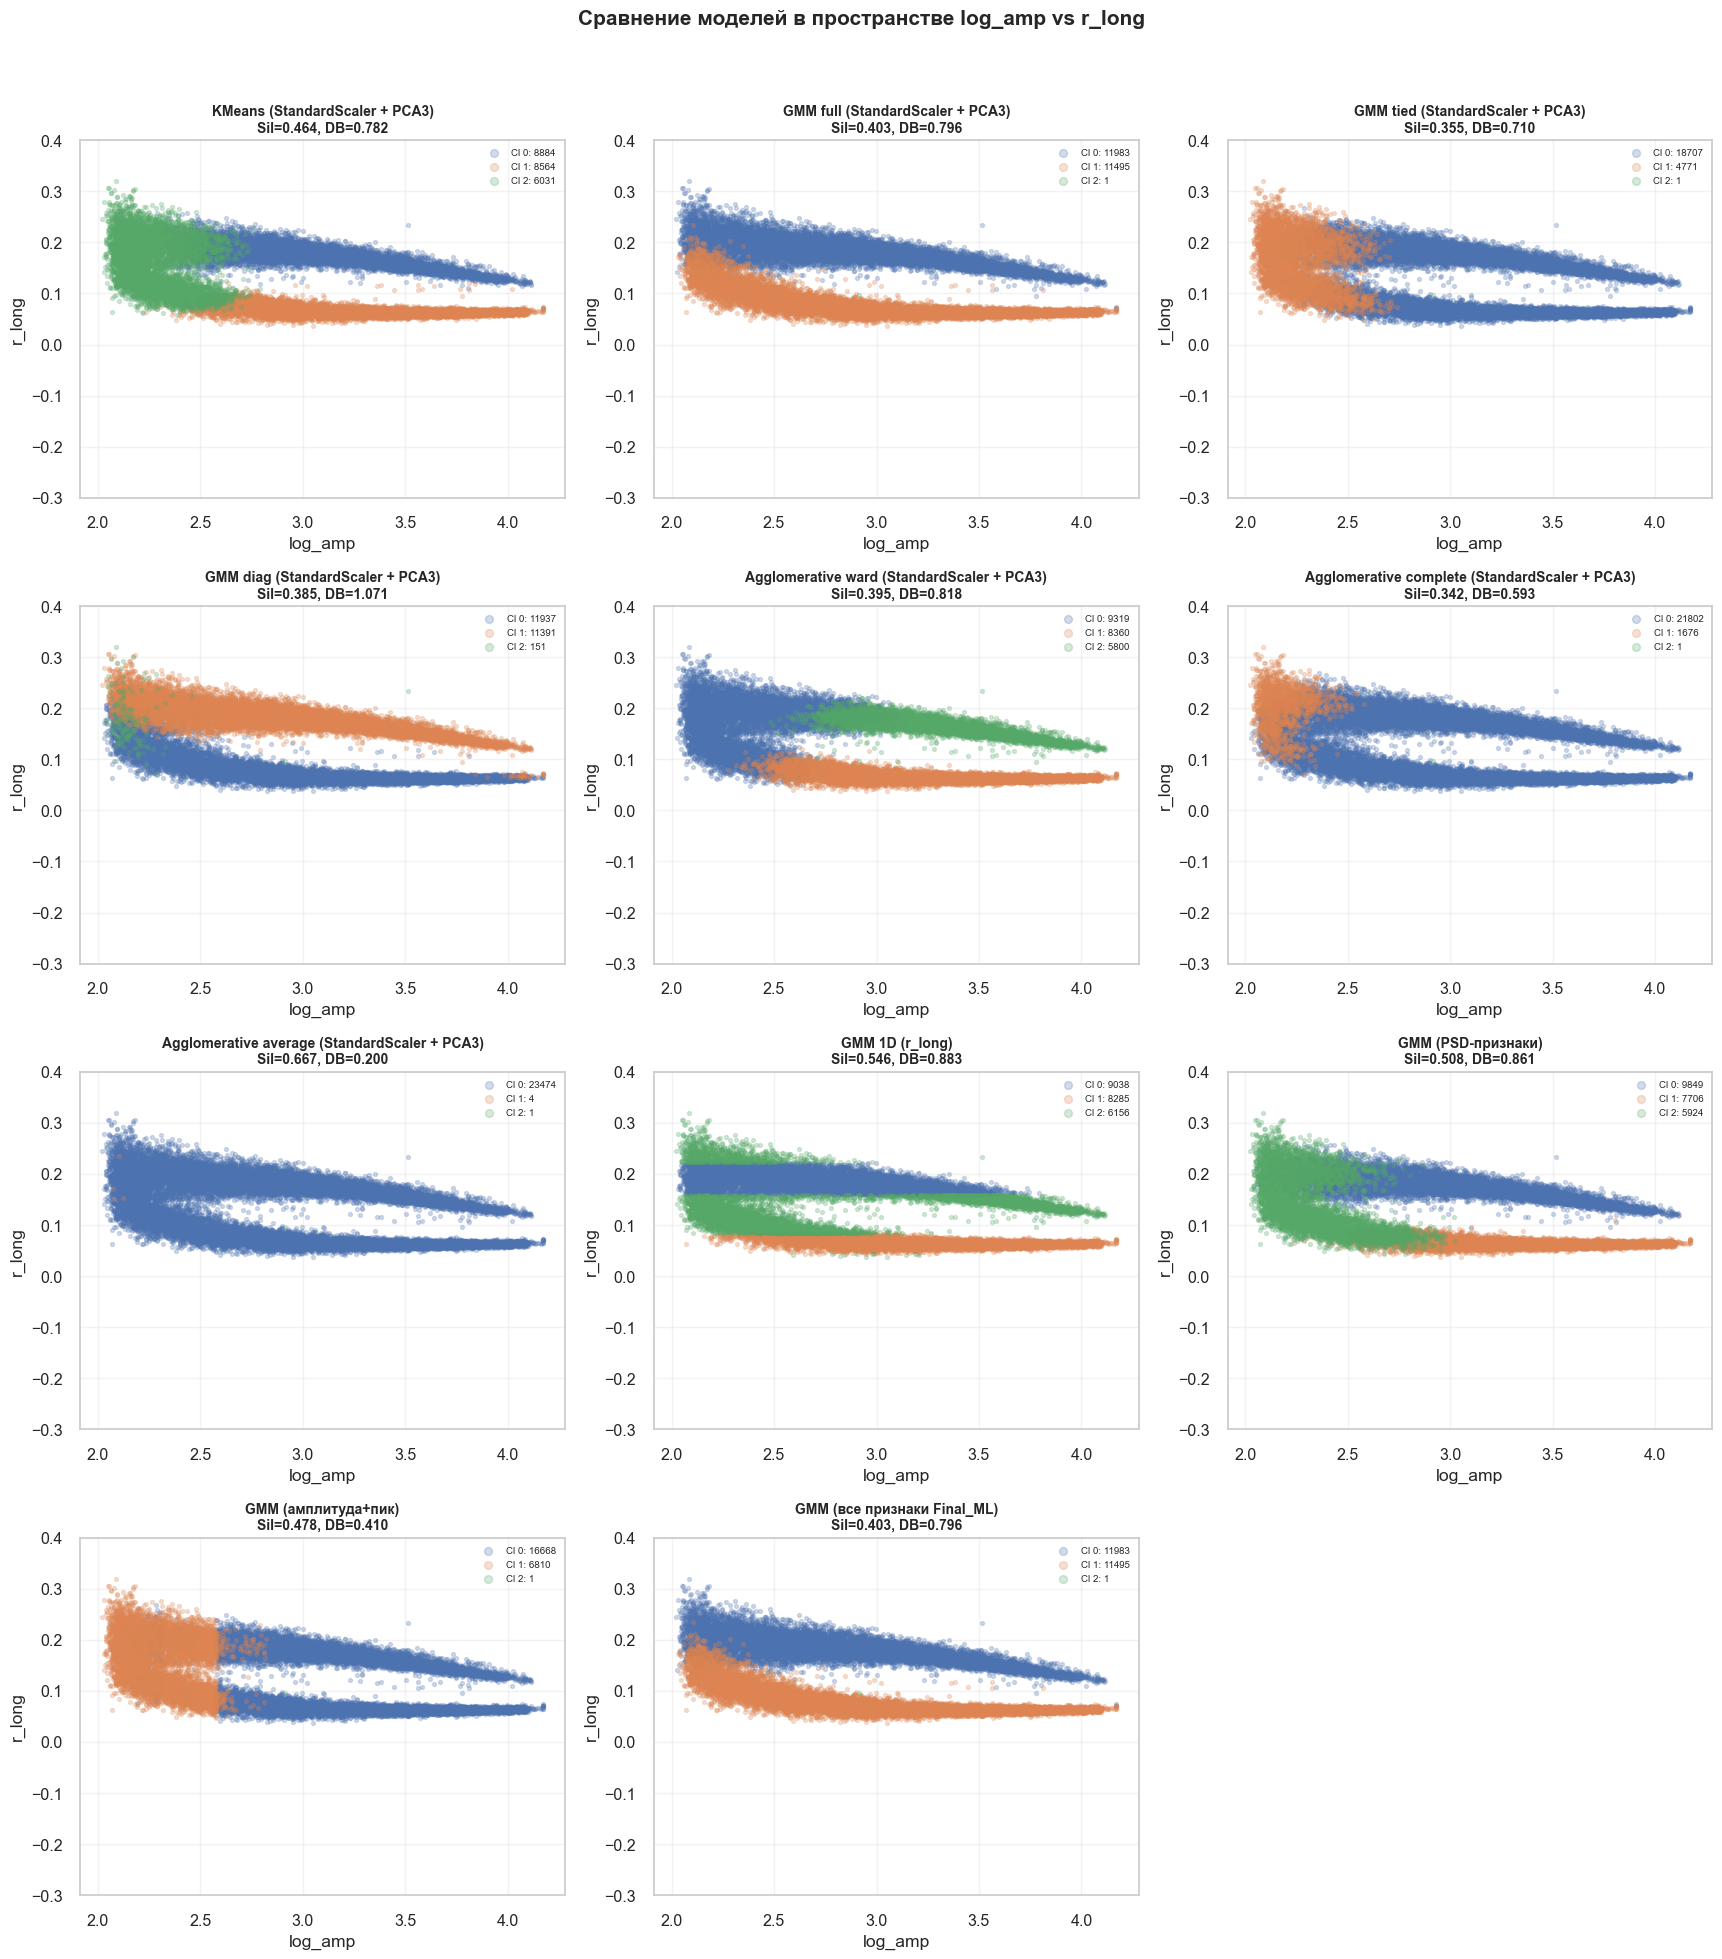

In [17]:
# Визуализация моделей
models_to_compare = [
    'KMeans (StandardScaler + PCA3)',
    'GMM full (StandardScaler + PCA3)',
    'GMM tied (StandardScaler + PCA3)',
    'GMM diag (StandardScaler + PCA3)',
    'Agglomerative ward (StandardScaler + PCA3)',
    'Agglomerative complete (StandardScaler + PCA3)',
    'Agglomerative average (StandardScaler + PCA3)',
    'GMM 1D (r_long)',
    'GMM (PSD-признаки)',
    'GMM (амплитуда+пик)',
    'GMM (все признаки Final_ML)'
]

models_to_compare = [
    model_name for model_name in models_to_compare
    if model_name in log_results
]

print("Модели для визуального сравнения:")
for model_name in models_to_compare:
    print("-", model_name)


final_features = ['r_long', 'r_short', 'ratio', 'asymmetry', 'log_amp']

X_features = feat[final_features].values

scaler_vis = StandardScaler()
X_scaled_vis = scaler_vis.fit_transform(X_features)

pca_vis = PCA(n_components=3, random_state=SEED)
X_pca_vis = pca_vis.fit_transform(X_scaled_vis)

df_pca_vis = pd.DataFrame(
    X_pca_vis,
    columns=['PC1', 'PC2', 'PC3']
)


n_models = len(models_to_compare)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5.8 * n_cols, 4.8 * n_rows)
)

axes = np.array(axes).reshape(-1)

for ax, model_name in zip(axes, models_to_compare):
    labels_model = log_results[model_name]['labels']
    sil_model = log_results[model_name]['silhouette']
    db_model = log_results[model_name]['davies_bouldin']

    for c in sorted(np.unique(labels_model)):
        mask = labels_model == c

        ax.scatter(
            df_pca_vis.loc[mask, 'PC1'],
            df_pca_vis.loc[mask, 'PC2'],
            s=8,
            alpha=0.35,
            label=f'Cl {c}: {mask.sum()}'
        )

    ax.set_title(
        f'{model_name}\nSil={sil_model:.3f}, DB={db_model:.3f}',
        fontsize=10,
        fontweight='bold'
    )

    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.grid(alpha=0.25)
    ax.legend(markerscale=2, fontsize=7, loc='best')

for ax in axes[len(models_to_compare):]:
    ax.axis('off')

plt.suptitle(
    'Сравнение моделей в общем PCA-пространстве',
    fontsize=15,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()


# 2. Интерпретируемое пространство log_amp vs r_long

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5.8 * n_cols, 4.8 * n_rows)
)

axes = np.array(axes).reshape(-1)

for ax, model_name in zip(axes, models_to_compare):
    labels_model = log_results[model_name]['labels']
    sil_model = log_results[model_name]['silhouette']
    db_model = log_results[model_name]['davies_bouldin']

    for c in sorted(np.unique(labels_model)):
        mask = labels_model == c

        ax.scatter(
            feat.loc[mask, 'log_amp'],
            feat.loc[mask, 'r_long'],
            s=8,
            alpha=0.25,
            label=f'Cl {c}: {mask.sum()}'
        )

    ax.set_title(
        f'{model_name}\nSil={sil_model:.3f}, DB={db_model:.3f}',
        fontsize=10,
        fontweight='bold'
    )

    ax.set_xlabel('log_amp')
    ax.set_ylabel('r_long')
    ax.set_ylim(-0.3, 0.4)
    ax.grid(alpha=0.25)
    ax.legend(markerscale=2, fontsize=7, loc='best')

for ax in axes[len(models_to_compare):]:
    ax.axis('off')

plt.suptitle(
    'Сравнение моделей в пространстве log_amp vs r_long',
    fontsize=15,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

**4. Вывод. Кластеризация, обучение и выбор лучшей модели**.

Выбор n_components=3 обусловлен физической постановкой задачи: необходимо выделить два типа частиц (гамма-кванты и нейтроны) и группу аномальных сигналов. 

Были проведены эксперименты с несколькими методами кластеризации: KMeans, GaussianMixture и AgglomerativeClustering. Для сравнения моделей использовались: Silhouette Score и Davies-Bouldin Score. **Формально** чем выше значение Silhouette Score, тем лучше разделены кластеры, а чем ниже значение Davies-Bouldin Score, тем компактнее и дальше друг от друга находятся группы объектов.

**Пришли к выводу**, что использовать Agglomerative average и GMM 1D (r_long) неправильно даже несмотря на высокие метрики так как наблюдается дисбаланс кластеров. С учетом визуального анализа необходимо использовать использовать  **GMM (все признаки_Final_ML)** StandardScaler + PCA(3) + GMM (Final_ML) как финальная модель.

**5. Подбор гиперпараметров и итоговое предсказание по модели GMM (все признаки_Final_ML)**

In [18]:
# Кластеризация под переменные

SEED = 42
np.random.seed(SEED)

X_features = feat.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

pca = PCA(n_components=3, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

print('Доля объяснённой дисперсии PCA:', pca.explained_variance_ratio_.round(4))
print('Суммарная объяснённая дисперсия:', pca.explained_variance_ratio_.sum().round(4))

gmm = GaussianMixture(
    n_components=3,
    covariance_type='full',
    reg_covar=1e-4,
    n_init=20,
    max_iter=500,
    random_state=SEED
)

raw_labels = gmm.fit_predict(X_pca)
unique, counts = np.unique(raw_labels, return_counts=True)
order = unique[np.argsort(counts)[::-1]]

mapping = {old: new for new, old in enumerate(order)}
final_labels = np.array([mapping[label] for label in raw_labels])

# Метрики качества
sil = silhouette_score(X_pca, final_labels)
db = davies_bouldin_score(X_pca, final_labels)

print('\nИТОГОВАЯ МОДЕЛЬ:')
print('GMM: n_components=3, covariance_type=full, reg_covar=1e-4, n_init=20')
print(f'Silhouette в PCA-пространстве: {sil:.4f}')
print(f'Davies-Bouldin в PCA-пространстве: {db:.4f}')

print('\nРаспределение сигналов по кластерам:')
for i in sorted(np.unique(final_labels)):
    cnt = np.sum(final_labels == i)
    print(f'  Кластер {i}: {cnt} сигналов ({cnt / len(final_labels) * 100:.1f}%)')

Доля объяснённой дисперсии PCA: [0.5299 0.2871 0.1342]
Суммарная объяснённая дисперсия: 0.9512

ИТОГОВАЯ МОДЕЛЬ:
GMM: n_components=3, covariance_type=full, reg_covar=1e-4, n_init=20
Silhouette в PCA-пространстве: 0.4025
Davies-Bouldin в PCA-пространстве: 0.7964

Распределение сигналов по кластерам:
  Кластер 0: 11983 сигналов (51.0%)
  Кластер 1: 11495 сигналов (49.0%)
  Кластер 2: 1 сигналов (0.0%)


,cluster,count,percent
0,0,11983,51.037097
1,1,11495,48.958644
2,2,1,0.004259


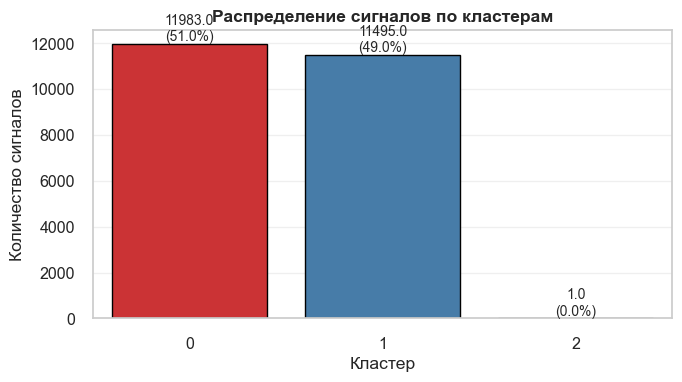

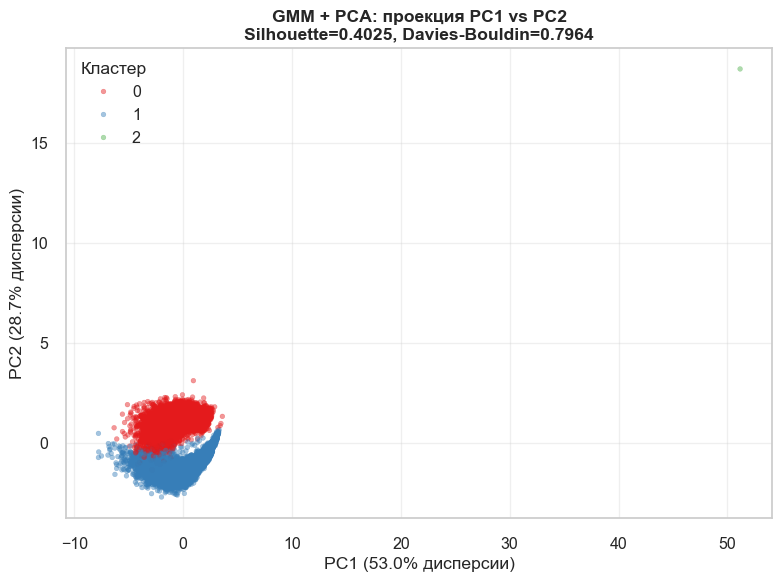

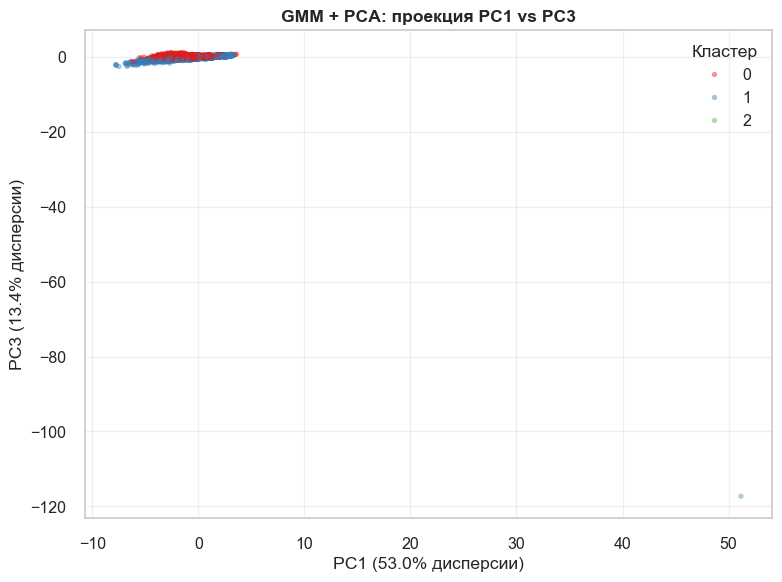

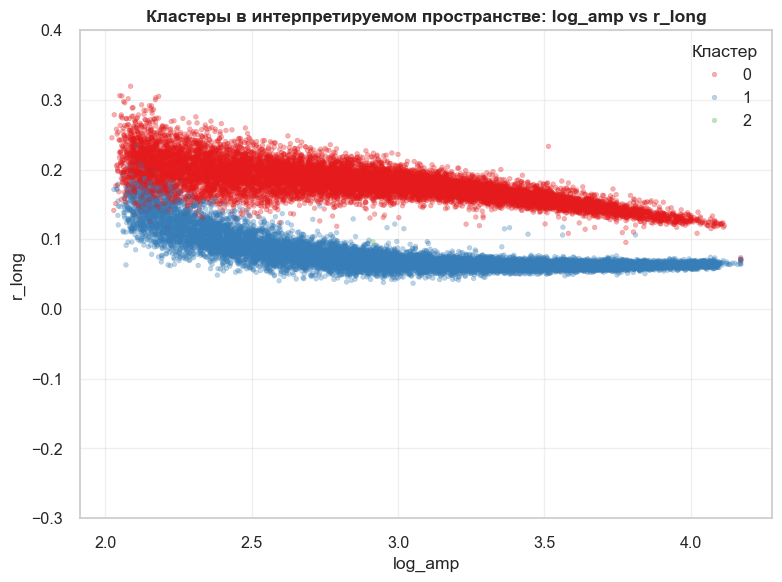

,r_long,r_short,ratio,asymmetry,log_amp
cluster,,,,,
0,0.1812,0.2410,0.7815,0.0090,2.8810
1,0.0791,0.1696,0.5525,0.0063,3.0128
2,0.0965,0.1385,0.6966,-6.4400,2.9142


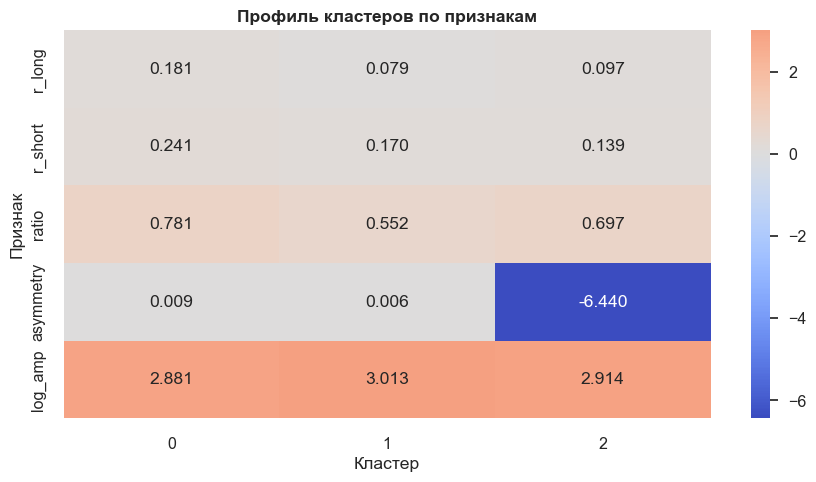

In [19]:
# Визуализация результатов
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_pca_vis = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2', 'PC3']
)

df_pca_vis['cluster'] = final_labels

cluster_counts = (
    pd.Series(final_labels)
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_counts.columns = ['cluster', 'count']
cluster_counts['percent'] = cluster_counts['count'] / len(final_labels) * 100

display(cluster_counts)

plt.figure(figsize=(7, 4))

sns.barplot(
    data=cluster_counts,
    x='cluster',
    y='count',
    palette='Set1',
    edgecolor='black'
)

plt.title('Распределение сигналов по кластерам', fontweight='bold')
plt.xlabel('Кластер')
plt.ylabel('Количество сигналов')
plt.grid(axis='y', alpha=0.3)

for i, row in cluster_counts.iterrows():
    plt.text(
        i,
        row['count'],
        f"{row['count']}\n({row['percent']:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pca_vis,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='Set1',
    s=12,
    alpha=0.45,
    edgecolor=None
)

plt.title(
    f'GMM + PCA: проекция PC1 vs PC2\n'
    f'Silhouette={sil:.4f}, Davies-Bouldin={db:.4f}',
    fontweight='bold'
)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% дисперсии)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% дисперсии)')
plt.legend(title='Кластер')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 3. PCA 2D: PC1 vs PC3

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_pca_vis,
    x='PC1',
    y='PC3',
    hue='cluster',
    palette='Set1',
    s=12,
    alpha=0.45,
    edgecolor=None
)

plt.title('GMM + PCA: проекция PC1 vs PC3', fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% дисперсии)')
plt.ylabel(f'PC3 ({pca.explained_variance_ratio_[2] * 100:.1f}% дисперсии)')
plt.legend(title='Кластер')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


if {'r_long', 'log_amp'}.issubset(feat.columns):
    df_phys_vis = feat.copy()
    df_phys_vis['cluster'] = final_labels

    plt.figure(figsize=(8, 6))

    sns.scatterplot(
        data=df_phys_vis,
        x='log_amp',
        y='r_long',
        hue='cluster',
        palette='Set1',
        s=12,
        alpha=0.35,
        edgecolor=None
    )

    plt.title('Кластеры в интерпретируемом пространстве: log_amp vs r_long', fontweight='bold')
    plt.xlabel('log_amp')
    plt.ylabel('r_long')
    plt.ylim(-0.3, 0.4)
    plt.legend(title='Кластер')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


profile_features = ['r_long', 'r_short', 'ratio', 'asymmetry', 'log_amp']

available_features = [col for col in profile_features if col in feat.columns]

df_profile = feat[available_features].copy()
df_profile['cluster'] = final_labels

cluster_profile = df_profile.groupby('cluster')[available_features].mean().round(4)

display(cluster_profile)

plt.figure(figsize=(9, 5))

sns.heatmap(
    cluster_profile.T,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0
)

plt.title('Профиль кластеров по признакам', fontweight='bold')
plt.xlabel('Кластер')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

In [20]:
# Профили кластеров: средние значения ключевых признаков Final_ML
tmp = feat.copy()
tmp['cluster'] = final_labels

features_to_analyze = [
    'r_long',
    'r_short',
    'ratio',
    'asymmetry',
    'log_amp'
]

cluster_profiles = tmp.groupby('cluster')[features_to_analyze].mean().round(4)
display(cluster_profiles)

,r_long,r_short,ratio,asymmetry,log_amp
cluster,,,,,
0,0.1812,0.2410,0.7815,0.0090,2.8810
1,0.0791,0.1696,0.5525,0.0063,3.0128
2,0.0965,0.1385,0.6966,-6.4400,2.9142


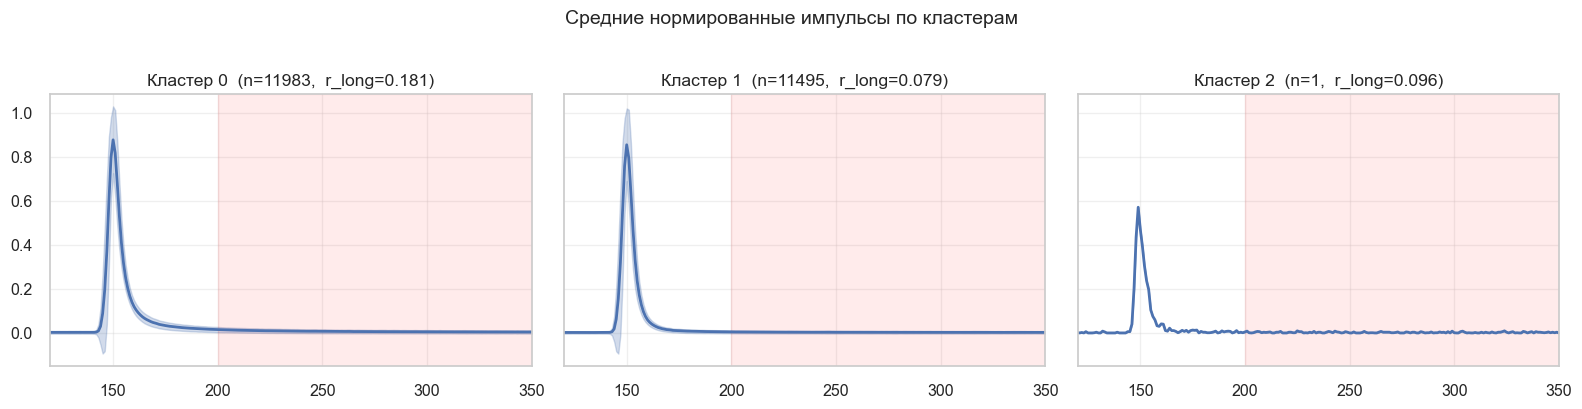

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for k, c in enumerate(sorted(np.unique(final_labels))):
    mask = final_labels == c
    waves_cluster = np.asarray(normalized_waveforms)[mask]
    mean_wave = waves_cluster.mean(axis=0)
    std_wave  = waves_cluster.std(axis=0)
    x = np.arange(len(mean_wave))
    axes[k].plot(x, mean_wave, linewidth=2, color='C0')
    axes[k].fill_between(x, mean_wave - std_wave, mean_wave + std_wave, 
                         color='C0', alpha=0.25)
                         
    axes[k].axvspan(200, 350, color='red', alpha=0.08)
    
    n_samples = mask.sum()
    mean_r_long = feat.loc[mask, 'r_long'].mean() if 'r_long' in feat.columns else np.nan
    
    axes[k].set_title(f'Кластер {c}  (n={n_samples},  r_long={mean_r_long:.3f})')
    axes[k].set_xlim(120, min(350, len(mean_wave)))
    axes[k].grid(True, alpha=0.3)

plt.suptitle('Средние нормированные импульсы по кластерам', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

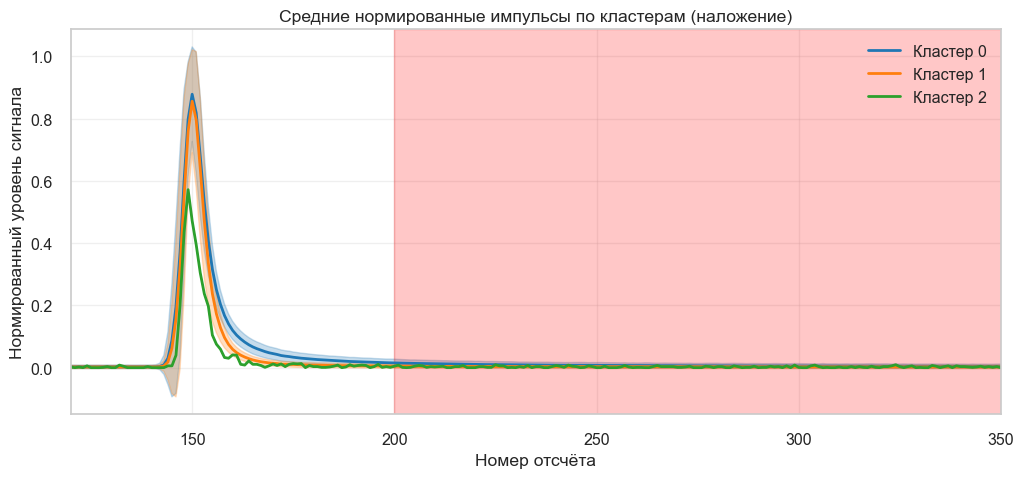

In [22]:
plt.figure(figsize=(12, 5))

colors = ['tab:blue', 'tab:orange', 'tab:green']

for k, c in enumerate(sorted(np.unique(final_labels))):
    mask = final_labels == c
    waves_cluster = np.asarray(normalized_waveforms)[mask]
    mean_wave = waves_cluster.mean(axis=0)
    std_wave  = waves_cluster.std(axis=0)
    x = np.arange(len(mean_wave))
    
    plt.plot(x, mean_wave, linewidth=2, color=colors[k], label=f'Кластер {c}')
    plt.fill_between(x, mean_wave - std_wave, mean_wave + std_wave, 
                     color=colors[k], alpha=0.25)
    
    plt.axvspan(200, 350, color='red', alpha=0.08)

plt.xlim(120, 350)
plt.xlabel('Номер отсчёта')
plt.ylabel('Нормированный уровень сигнала')
plt.title('Средние нормированные импульсы по кластерам (наложение)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**5. Вывод. Подбора гиперпараметров и предсказания**

Была выполнена итоговая кластеризация сигналов с использованием финального пайплайна **Final_ML_GMM_PCA**: масштабирование признаков с помощью **StandardScaler**, снижение размерности методом **PCA** до трёх компонент и кластеризация алгоритмом **GaussianMixture**.

Метод **PCA** позволил перейти от исходного набора признаков к более компактному пространству, сохранив основную часть информации о различиях между сигналами. Это снизило влияние коррелированных признаков и сделало кластеризацию более устойчивой.

Визуализация в пространстве главных компонент и в интерпретируемых координатах log_amp и r_long позволяют проверить структуру кластеров и оценить разделение. 

In [23]:
# Вывод результата
mapping = {}
next_id = 0  
ordered_ids = []

for v in final_labels:
    if v not in mapping:
        mapping[v] = next_id
        next_id += 1
    ordered_ids.append(mapping[v])

submit = pd.DataFrame({
    'index': np.arange(len(final_labels)),
    'cluster': ordered_ids
})

submit.to_csv('submission.csv', index=False)

print(" Файл 'submission.csv' успешно сохранён.")
print("\n Распределение по кластерам (cluster):")
print(submit['cluster'].value_counts().sort_index())
print("\n Первые 10 строк:")
display(submit.head(10))

 Файл 'submission.csv' успешно сохранён.

 Распределение по кластерам (cluster):
cluster
0    11983
1    11495
2        1
Name: count, dtype: int64

 Первые 10 строк:


,index,cluster
0,0,0
1,1,1
2,2,1
3,3,0
4,4,1
5,5,0
6,6,0
7,7,0
8,8,1
9,9,0


**6. ИТОГОВЫЙ ВЫВОД**

В ходе работы выполнена полная обработка и анализ 23 479 сигналов сцинтилляционного детектора, представленных 500 временными отсчетами. Нужно было разделить сигналы на три группы: два типа частиц (гамма-кванты и нейтроны) и аномалии. Для этого были загружены, обработаны и проанализированы предоставленные данные. Исходный набор данных не подходил для кластеризации, поэтому из них были выделены новые признаки.

**Анализ данных.** Сигналы оказались отрицательными импульсами, уровень держится около одного занчения, потом в районе 150-го отсчёта резко падает вниз, а затем возвращается обратно. Минимум почти у всех сигналов находится на 149-150-м отсчёте, что позволило зафиксировать точку для расчёта признаков (150). Обнаружено 28 сигналов с аномально высокой амплитудой.

**Предобработка.** Была осуществлена корреткировка базовой линии, инверсия импульсов и нормализация. Эти шаги обеспечили стабильное и сопоставимое представление сигналов для дальнейшего анализа.

**Выбор признаков.** Извлечение признаков (r_long, r_short, ratio, asymmetry, log_amp) позволило количественно описать форму импульсов, выделив различия между типами частиц и аномальными сигналами.

**Выбор параметров, признаков, моделей, кластеризация.** Сразу было выбрано 3 кластера по условиям задачи. Сначала мы использоваля один признак r_long и вычитался шум по первым 120 отсчётам результат на kaggle получилося 0,65. Далее снижено окно до 94, что улучшило результат до 0,75. Были добавлены остальные признаки и настроен baseline это улучшило результат он получился (Kaggle = 0.84). Пробовались различные методы кластеризации, но на освновании визуализации выбран GMM (все признаки) он умеет находить кластеры разной формы. 

**Финальная модель дает распределение:**
- Кластер 0: 11983 сигналов (51.0%)
- Кластер 1: 11495 сигналов (49.0%)
- Кластер 2: 1 сигнал (0.0%)

**Вывод:**
В получении хороших результатов нам помогло правильное окно для вычитания шума (94 отсчёта) и сформированный набор из пяти признаков. Добавление новых признаков часто только ухудшало результат, поэтому мы остановились на данном наборе. Также нам помогло выбо правильной модели на основии визуализации кластеров (GMM (все признаки_Final_ML) - StandardScaler + PCA(3) + GMM). 


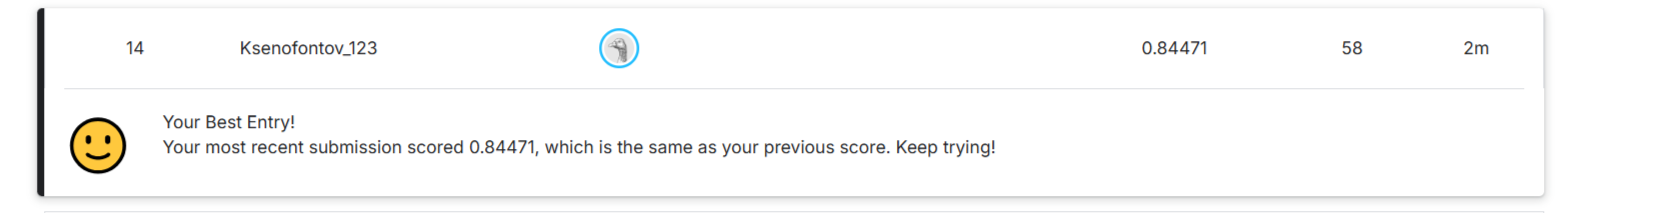